# 033_bis — Signal Evaluation (`data/test/`)

Same logic as `033_signal_evaluation.ipynb` — no hand-drawn mask, same cross-modal pseudo ground truth (`scripts.pseudo_mask`) and the same unsupervised stroke-coherence axis (`scripts.stroke_stats`) — run on `data/test/` instead of the main train/val/test corpus.

Why bother, given `evaluation.md` §3 already notes that the main corpus (`data/ir`/`data/rgb`, scored in `033`) has no documented hidden content — the only RGB/IR difference there is paint-stroke thickness, so `033`'s ranking reflects that, not detection ability? `data/test/` (`case`, `green`, `modern`, `total`) is the opposite case: every image there is known to carry hidden detail from a specific, identified cause (underdrawing, pentimento, reused support, etc.). The same data-derived pseudo-mask that measures an artifact on the main corpus is scoring a real phenomenon here — it just still isn't a hand-drawn reference. That refinement (an actual annotated mask, `scripts.detection` against ground truth rather than a proxy) is left for a dedicated notebook, not this one — see `ground-truth-annotation.md`.

- **Detection** (`scripts.pseudo_mask` + `scripts.detection`) — the cross-modal pseudo-mask, AUROC / average precision, exactly as in `033`.
- **Stroke coherence** (`scripts.stroke_stats`) — unchanged, fully unsupervised.

Read like `033` §4/§5/§6: `auroc` primary ranking, `lift` relative to chance, agreement between the two axes in §6 is the real result. The same construction caveat applies — the pseudo-mask shares its mathematical form with the structural delta, so compare signal types via §6/stroke-coherence, not via §4 alone.

In [2]:
import sys
from pathlib import Path

project_root = Path().absolute()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image
from scipy.stats import spearmanr

from scripts.calibration import learned_zscore
from scripts.config import settings
from scripts.dataset import pad_to_multiple
from scripts.delta_analysis import compute_local_stats, compute_ssim_components
from scripts.detection import rank_signals
from scripts.pseudo_mask import cross_modal_pseudo_mask
from scripts.stroke_stats import stroke_coherence
from scripts.trainer import load_model
from scripts.trainer_nll import load_model_nll
from scripts.visualization_nll import plot_signal_comparison

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {gpus}")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Test images

Every `(rgb, ir)` pair under `data/test/` — a handful of purpose-selected images, not a split of the training corpus (`data/test/` is never read by `020`/`021`/`022`), so nothing here was seen in training regardless of which architecture's checkpoint is loaded below.

In [4]:
MASK_PERCENTILE = 95.0  # top 5% of the pseudo-mask score counts as positive

TEST_RGB_DIR = project_root / "data" / "test" / "rgb"
TEST_IR_DIR = project_root / "data" / "test" / "ir"

rgb_paths = sorted(TEST_RGB_DIR.glob("*.jpg")) if TEST_RGB_DIR.exists() else []
eval_pairs = [
    (p, TEST_IR_DIR / p.name) for p in rgb_paths if (TEST_IR_DIR / p.name).exists()
]
print(f"Test images: {len(eval_pairs)} | {[p.stem for p, _ in eval_pairs]}")

if len(eval_pairs) < 2:
    raise RuntimeError(
        "Need at least 2 images in data/test/ for the ranking's std and §6's rank "
        "correlation to mean anything."
    )

Test images: 4 | ['case', 'green', 'modern', 'total']


## 2. What the pseudo-mask sees

Two factors multiplied: is there IR structure here at all, and is it explained by the RGB? The **absolute** correlation is used — an inverted IR (dark paint reading bright) is fully explained, just with opposite sign. Identical to `033` §2, shown here for the first `data/test/` image.

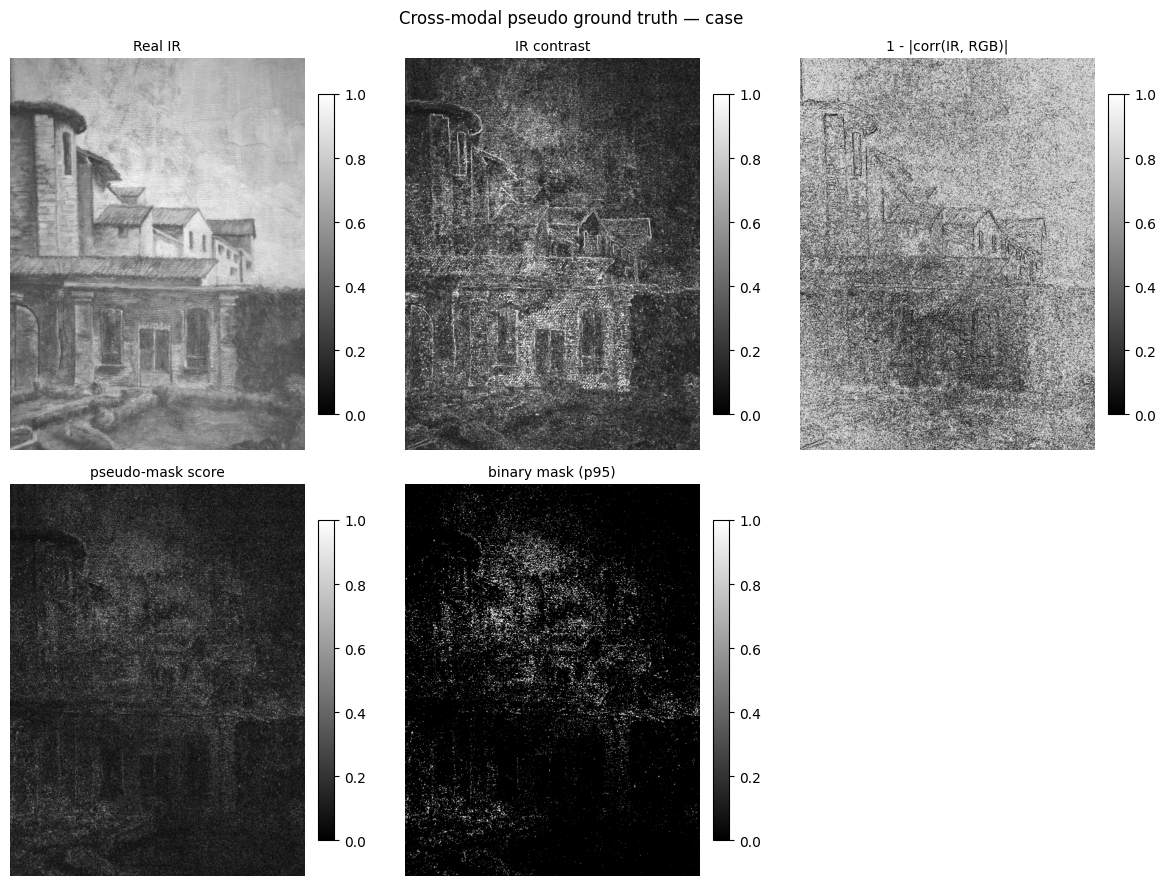

In [5]:
def load_pair(rgb_path: Path, ir_path: Path) -> tuple[np.ndarray, np.ndarray]:
    rgb = np.array(Image.open(rgb_path).convert("RGB")).astype(np.float32) / 255.0
    ir = np.array(Image.open(ir_path).convert("L")).astype(np.float32) / 255.0
    return rgb, ir


rgb_demo, ir_demo = load_pair(*eval_pairs[0])
mask_demo = cross_modal_pseudo_mask(rgb_demo, ir_demo)

fig = plot_signal_comparison(
    ir_demo,
    {
        "IR contrast": mask_demo.ir_contrast,
        "1 - |corr(IR, RGB)|": 1.0 - mask_demo.cross_structure,
        "pseudo-mask score": mask_demo.score,
        f"binary mask (p{MASK_PERCENTILE:g})": mask_demo.binarize(
            MASK_PERCENTILE
        ).astype(float),
    },
    title=f"Cross-modal pseudo ground truth — {eval_pairs[0][0].stem}",
    vrange=(0.0, 1.0),
)
plt.show()

## 3. Candidate signals, per model

Identical construction to `033` §3:

- deterministic architectures → raw delta `|IR - pred|` and structural delta `1 - structure`;
- NLL architectures, both loss variants → raw delta `|IR - mu|` and `|z| = |(IR - mu) / sigma|`.

Images here are full paintings of varying size, not fixed-size training patches, so each is padded to `settings.PATCH_MULTIPLE` and predicted in one shot (same pattern as `050`/`051`/`060`), rather than run through `build_dataset`.

In [6]:
# Every architecture with a checkpoint on disk is scored; missing ones are
# reported and skipped, so this runs against whatever has been trained so far.
DET_ARCHS = [
    "unet",
    "resunet",
    "attention_unet",
    "efficientnet_unet",
    "unet_v2",
    "unet_restormer",
]
NLL_ARCHS = ["unet_nll", "resunet_nll", "attention_unet_nll", "efficientnet_unet_nll"]
BETA_MODEL_DIR = settings.MODELS_DIR / "nll_beta"
BETA = 0.5

det_models = {}
for arch in DET_ARCHS:
    try:
        det_models[arch] = load_model(arch, model_dir=settings.MODELS_DIR)
    except (FileNotFoundError, OSError) as exc:
        print(f"[skip] {exc}")

nll_models = {}
for arch in NLL_ARCHS:
    for variant, model_dir in (
        ("gaussian", settings.MODELS_DIR),
        ("beta", BETA_MODEL_DIR),
    ):
        loss_name = "gaussian_nll" if variant == "gaussian" else "beta_nll"
        try:
            nll_models[f"{arch} ({variant})"] = load_model_nll(
                arch, model_dir=model_dir, loss_name=loss_name, beta=BETA
            )
        except (FileNotFoundError, OSError) as exc:
            print(f"[skip] {exc}")

n_signals = 2 * (len(det_models) + len(nll_models))
print(f"\nLoaded {len(det_models)} deterministic, {len(nll_models)} NLL models")
print(f"-> {n_signals} candidate signals per image")

# Fail here rather than four cells downstream: below three signals the ranking
# has nothing to rank and §6's rank correlation is trivially +/-1, which reads
# like a result but is an artefact of the sample size.
if n_signals < 3:
    raise RuntimeError(
        f"Only {n_signals} candidate signals available — at least 3 are needed "
        "for the ranking and the rank correlation to mean anything. Train the "
        "missing architectures (020/021/022) or point MODELS_DIR at a tree that "
        "holds their checkpoints."
    )

2026-08-19 22:02:53.852059: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-19 22:02:53.852083: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-19 22:02:53.852087: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-19 22:02:53.852098: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-19 22:02:53.852106: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



Loaded 6 deterministic, 8 NLL models
-> 28 candidate signals per image


In [7]:
def structural_delta(ir, pred):
    """``1 - local SSIM structure`` between the real and predicted IR."""
    stats = compute_local_stats(ir, pred)
    return 1.0 - compute_ssim_components(stats).structure


def signals_for(rgb: np.ndarray, ir: np.ndarray) -> dict[str, np.ndarray]:
    """Build every candidate magnitude map for one full-size (rgb, ir) pair."""
    padded, _ = pad_to_multiple(tf.constant(rgb), multiple=settings.PATCH_MULTIPLE)
    h, w = ir.shape
    batch = padded[tf.newaxis, ...]

    signals = {}
    for name, model in det_models.items():
        pred = model.predict(batch, verbose=0)[0, :h, :w, 0]
        signals[f"{name} delta"] = np.abs(ir - pred)
        signals[f"{name} structural"] = structural_delta(ir, pred)
    for name, model in nll_models.items():
        pred = model.predict(batch, verbose=0)[0, :h, :w, :]
        mu, sigma = pred[..., 0], np.exp(0.5 * pred[..., 1])
        signals[f"{name} delta"] = np.abs(ir - mu)
        signals[f"{name} |z|"] = np.abs(learned_zscore(ir, mu, sigma))
    return signals


auroc_rows: dict[str, list[float]] = {}
ap_rows: dict[str, list[float]] = {}
lift_rows: dict[str, list[float]] = {}
coherence_rows: dict[str, list[float]] = {}

for rgb_path, ir_path in eval_pairs:
    rgb, ir = load_pair(rgb_path, ir_path)
    mask = cross_modal_pseudo_mask(rgb, ir).binarize(MASK_PERCENTILE)
    signals = signals_for(rgb, ir)

    for name, result in rank_signals(signals, mask).items():
        auroc_rows.setdefault(name, []).append(result.auroc)
        ap_rows.setdefault(name, []).append(result.average_precision)
        lift_rows.setdefault(name, []).append(result.lift)
    for name, signal in signals.items():
        coherence_rows.setdefault(name, []).append(stroke_coherence(signal).coherence)

    print(f"{rgb_path.stem}: {len(signals)} signals scored")

2026-08-19 22:03:01.165226: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


case: 28 signals scored
green: 28 signals scored
modern: 28 signals scored
total: 28 signals scored


## 4. Detection ranking

`auroc` is prevalence-independent and is the primary ranking. `lift` is average precision relative to chance: how much better than random the top of the ranking is. `std` across images is the honest error bar — a difference smaller than it means nothing, and with only a handful of `data/test/` images this bar is wide.

**Read like with like.** The pseudo-mask shares its mathematical form with the structural delta — both are built on the same local windowed structure statistic — so a structural signal scores well against it *by construction*, not on merit. Comparing architectures **within** one signal type is sound; comparing signal types against each other on this axis alone is not, which is what §5/§6 are for.

In [16]:
def summarise(rows):
    return {name: (float(np.mean(v)), float(np.std(v))) for name, v in rows.items()}


auroc_mean = summarise(auroc_rows)
ap_mean = summarise(ap_rows)
lift_mean = summarise(lift_rows)
ranking = sorted(auroc_mean, key=lambda n: auroc_mean[n][0], reverse=True)

col_w = 40
print("signal".ljust(col_w) + "auroc".ljust(18) + "avg_prec".ljust(18) + "lift")
print("-" * (col_w + 54))
for name in ranking:
    a, a_sd = auroc_mean[name]
    p, _ = ap_mean[name]
    fold, _ = lift_mean[name]
    print(f"{name.ljust(col_w)}{a:.4f} ± {a_sd:.3f}   {p:.4f}            {fold:.2f}x")

signal                                  auroc             avg_prec          lift
----------------------------------------------------------------------------------------------
unet_restormer structural               0.8120 ± 0.037   0.2203            4.41x
unet_v2 structural                      0.8119 ± 0.029   0.2182            4.36x
resunet structural                      0.7861 ± 0.048   0.1890            3.78x
efficientnet_unet structural            0.7849 ± 0.021   0.1916            3.83x
attention_unet structural               0.7707 ± 0.052   0.1786            3.57x
unet structural                         0.7576 ± 0.048   0.1544            3.09x
attention_unet delta                    0.5912 ± 0.043   0.0938            1.88x
unet delta                              0.5895 ± 0.041   0.0925            1.85x
resunet delta                           0.5827 ± 0.042   0.0897            1.79x
attention_unet_nll (gaussian) |z|       0.5791 ± 0.057   0.0929            1.86x
efficientnet_u

### Per-image breakdown

The mean/std above average over all `data/test/` images, which can hide a
signal that performs very differently on one image than another — e.g. a
strong result specifically on `modern` diluted by weaker results on
`case`/`green`/`total` (`evaluation.md` §6, point 2). One column per
image, same signal order as the ranking above.

In [17]:
image_stems = [p.stem for p, _ in eval_pairs]
header_cols = "".join(stem.rjust(10) for stem in image_stems)

print("signal".ljust(col_w) + header_cols)
print("-" * (col_w + 10 * len(image_stems)))
for name in ranking:
    row = "".join(f"{v:.3f}".rjust(10) for v in auroc_rows[name])
    print(f"{name.ljust(col_w)}{row}")

signal                                        case     green    modern     total
--------------------------------------------------------------------------------
unet_restormer structural                    0.859     0.825     0.757     0.807
unet_v2 structural                           0.837     0.834     0.765     0.812
resunet structural                           0.843     0.805     0.711     0.785
efficientnet_unet structural                 0.809     0.771     0.759     0.801
attention_unet structural                    0.823     0.796     0.685     0.779
unet structural                              0.792     0.793     0.677     0.769
attention_unet delta                         0.570     0.616     0.533     0.646
unet delta                                   0.578     0.622     0.527     0.631
resunet delta                                0.583     0.613     0.514     0.621
attention_unet_nll (gaussian) |z|            0.587     0.617     0.483     0.629
efficientnet_unet delta     

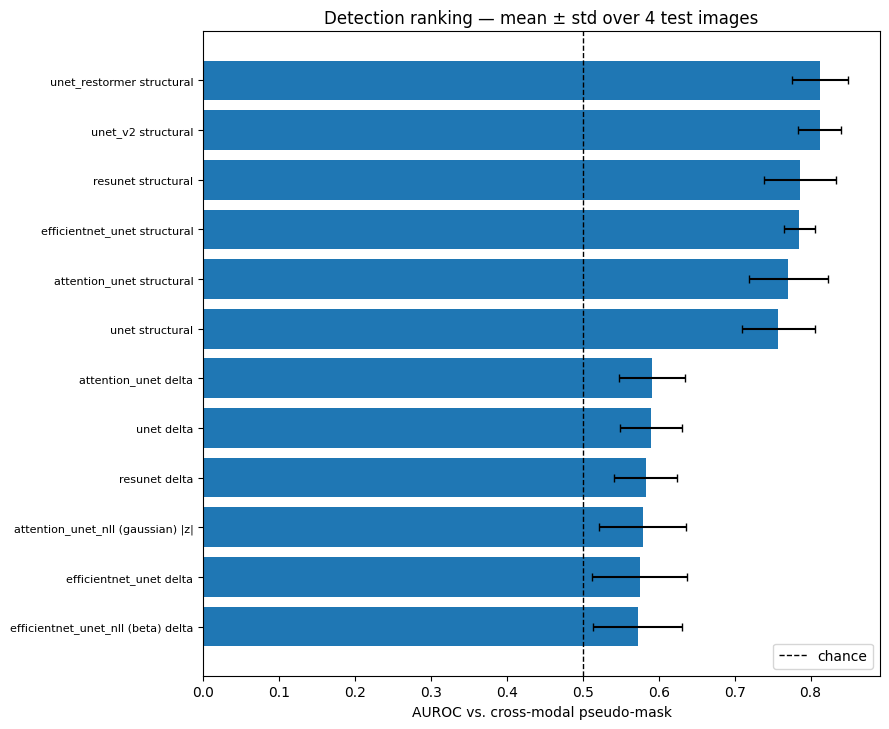

In [10]:
top = ranking[:12]
fig, ax = plt.subplots(figsize=(9, 0.45 * len(top) + 2))
y = np.arange(len(top))
ax.barh(
    y,
    [auroc_mean[n][0] for n in top],
    xerr=[auroc_mean[n][1] for n in top],
    capsize=3,
)
ax.axvline(0.5, color="k", ls="--", lw=1, label="chance")
ax.set_yticks(y)
ax.set_yticklabels(top, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("AUROC vs. cross-modal pseudo-mask")
ax.set_title(f"Detection ranking — mean ± std over {len(eval_pairs)} test images")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Stroke coherence — the unsupervised axis

No reference at all: how much of each signal is oriented, line-like structure rather than isotropic noise. Read it with suspicion — a model with patch-stitching seams or `Conv2DTranspose` checkerboarding scores high while revealing nothing.

In [18]:
coherence_mean = summarise(coherence_rows)
by_coherence = sorted(coherence_mean, key=lambda n: coherence_mean[n][0], reverse=True)

print("signal".ljust(col_w) + "coherence")
print("-" * (col_w + 20))
for name in by_coherence:
    c, c_sd = coherence_mean[name]
    print(f"{name.ljust(col_w)}{c:.4f} ± {c_sd:.3f}")

signal                                  coherence
------------------------------------------------------------
unet_v2 structural                      0.3287 ± 0.022
efficientnet_unet structural            0.3163 ± 0.025
unet_restormer structural               0.3162 ± 0.015
attention_unet structural               0.3107 ± 0.014
unet structural                         0.2971 ± 0.008
resunet structural                      0.2939 ± 0.011
attention_unet_nll (beta) delta         0.2369 ± 0.060
attention_unet_nll (beta) |z|           0.2337 ± 0.056
efficientnet_unet_nll (beta) |z|        0.2296 ± 0.036
unet_nll (gaussian) delta               0.2267 ± 0.055
unet_nll (beta) |z|                     0.2246 ± 0.048
efficientnet_unet_nll (gaussian) delta  0.2238 ± 0.056
unet_nll (beta) delta                   0.2234 ± 0.051
efficientnet_unet delta                 0.2232 ± 0.054
unet_v2 delta                           0.2218 ± 0.066
efficientnet_unet_nll (beta) delta      0.2215 ± 0.048
attention

## 6. Do the two axes agree?

They are wrong in different ways, so their agreement is the real result. A high rank correlation means both references point at the same signal and the conclusion is robust; a low one means at least one of them is measuring an artefact, and neither ranking should be trusted on its own.

Spearman(auroc, coherence) = 0.523 over 28 signals


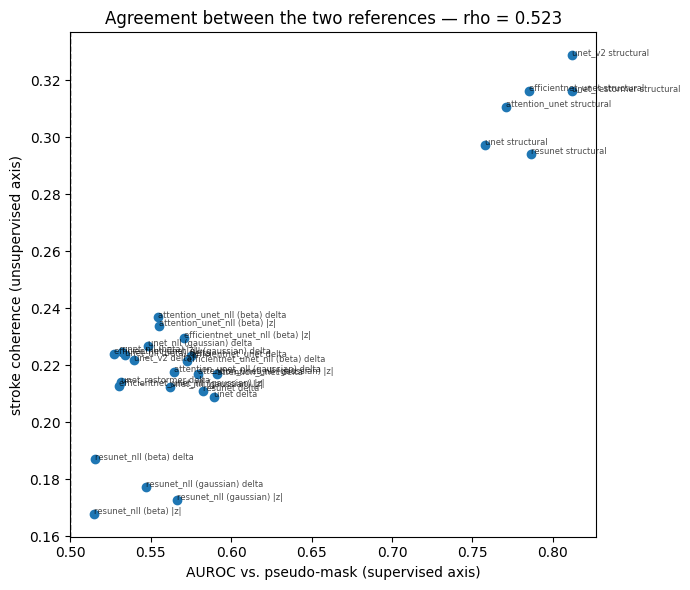

In [12]:
names = list(auroc_mean)
x = [auroc_mean[n][0] for n in names]
y = [coherence_mean[n][0] for n in names]
rho = spearmanr(x, y).statistic

print(f"Spearman(auroc, coherence) = {rho:.3f} over {len(names)} signals")

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(x, y)
for name, xi, yi in zip(names, x, y):
    ax.annotate(name, (xi, yi), fontsize=6, alpha=0.7)
ax.axvline(0.5, color="k", ls="--", lw=1)
ax.set_xlabel("AUROC vs. pseudo-mask (supervised axis)")
ax.set_ylabel("stroke coherence (unsupervised axis)")
ax.set_title(f"Agreement between the two references — rho = {rho:.3f}")
plt.tight_layout()
plt.show()